# Tema 1. Introducción al aprendizaje automático

##     1.2. Supervisado vs. no supervisado

In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Cargar el dataset del Titanic
df = sns.load_dataset('titanic')

# Mostrar algunas columnas clave
df[['age', 'sex', 'pclass', 'fare', 'survived']].head()

,age,sex,pclass,fare,survived
0,22.0,male,3,7.2500,0
1,38.0,female,1,71.2833,1
2,26.0,female,3,7.9250,1
3,35.0,female,1,53.1000,1
4,35.0,male,3,8.0500,0


## 1.3 Regresión vs Clasificación

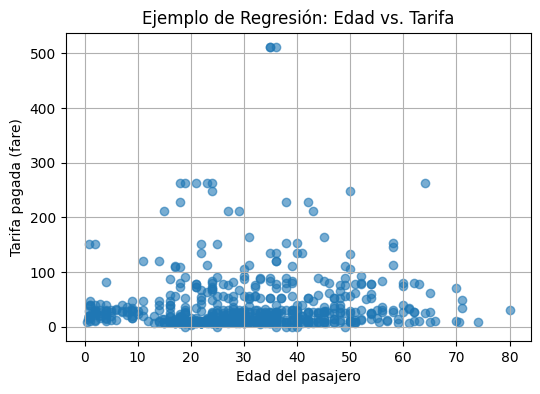

In [2]:
# Código y figura 1

# Cargar y limpiar el dataset
df = sns.load_dataset('titanic').dropna(subset=['age', 'fare'])

# Visualizar relación entre edad y tarifa pagada
plt.figure(figsize=(6, 4))
plt.scatter(df['age'], df['fare'], alpha=0.6)
plt.title('Ejemplo de Regresión: Edad vs. Tarifa')
plt.xlabel('Edad del pasajero')
plt.ylabel('Tarifa pagada (fare)')
plt.grid(True)
plt.show()


Esta visualización (Gráfica 1) muestra cómo la tarifa (fare) varía de forma continua respecto a la edad. No hay clases fijas, sino un rango abierto de valores posibles. El modelo de regresión buscaría una función que relacione ambas variables.



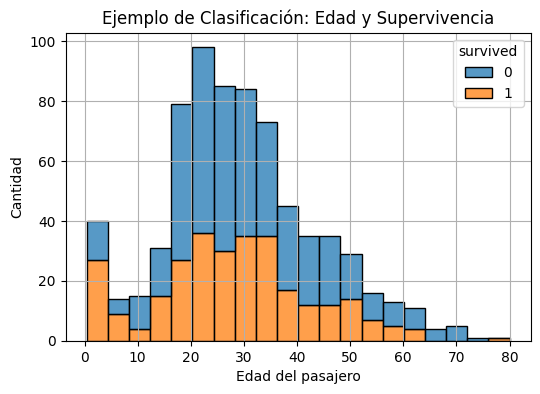

In [3]:
# Código y figura 2

# Cargar y limpiar el dataset
df = sns.load_dataset('titanic').dropna(subset=['age', 'fare'])

# Histograma con variable categórica `survived`
plt.figure(figsize=(6, 4))
sns.histplot(df, x='age', hue='survived', multiple='stack', bins=20)
plt.title('Ejemplo de Clasificación: Edad y Supervivencia')
plt.xlabel('Edad del pasajero')
plt.ylabel('Cantidad')
plt.grid(True)
plt.show()


En la Gráfica 2 se observa cómo la distribución de pasajeros sobrevivientes y no sobrevivientes varía con la edad. Un modelo de clasificación entrenado con estas variables intentaría predecir la clase (0 o 1) de nuevos casos

## Subtema 1.4 – Valores continuos

Este gráfico muestra que la mayoría de los pasajeros pagaron tarifas relativamente bajas, aunque existen algunos valores extremos. La variable fare es continua porque puede adoptar una gama amplia de valores, sin limitaciones a clases o grupos cerrados.

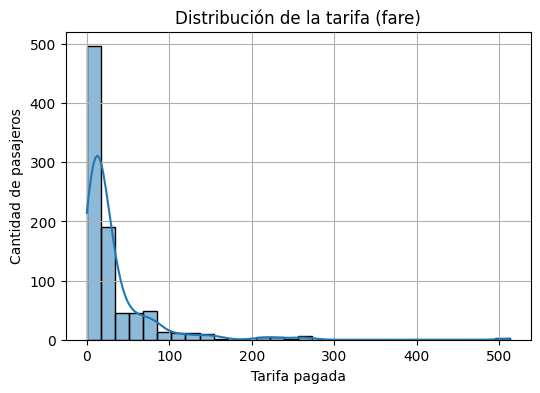

In [4]:
#Figura 4. Visualización de variables continuas.

# Cargar dataset
df = sns.load_dataset('titanic')

# Visualizar la distribución de la tarifa pagada
plt.figure(figsize=(6, 4))
sns.histplot(df['fare'].dropna(), bins=30, kde=True)
plt.title('Distribución de la tarifa (fare)')
plt.xlabel('Tarifa pagada')
plt.ylabel('Cantidad de pasajeros')
plt.grid(True)
plt.show()


## Subtema 1.5 – Categorías o clases; valores discretos

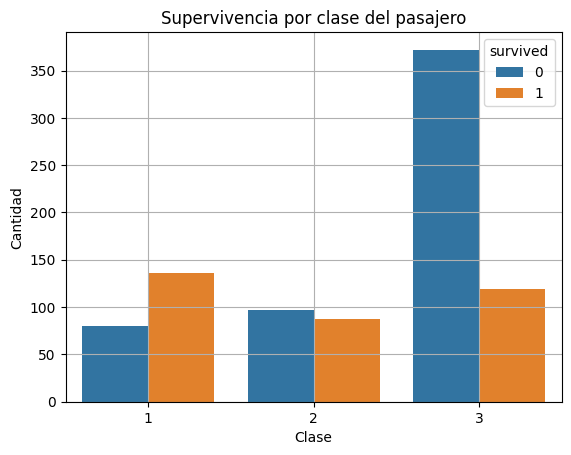

In [5]:
# Cargar datos
df = sns.load_dataset('titanic')

# Clasificar por clase del pasajero
sns.countplot(data=df, x='pclass', hue='survived')
plt.title('Supervivencia por clase del pasajero')
plt.xlabel('Clase')
plt.ylabel('Cantidad')
plt.grid(True)
plt.show()


Este gráfico de barras muestra cómo la categoría pclass influye en las tasas de supervivencia. A diferencia de una variable continua, solo hay tres clases posibles (1, 2, 3), y cada una agrupa múltiples observaciones.

# Tema 2. Métricas de evaluación en modelos de aprendizaje automático

## 2.1 Métricas de evaluación

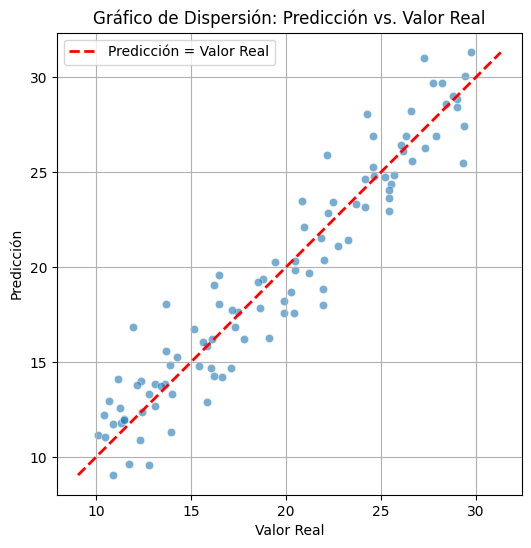

In [ ]:
# Gráfica de dispersión simple que muestre predicción vs. valor real para regresión (línea ideal + puntos), para introducir el concepto de “ajuste al valor real”.

import numpy as np

# Simular datos de predicción y valor real
np.random.seed(42)
n_samples = 100
real_values = 10 + 2 * np.random.rand(n_samples) * 10
predictions = real_values + np.random.randn(n_samples) * 2

# Crear DataFrame
df_eval = pd.DataFrame({'Valor Real': real_values, 'Predicción': predictions})

# Crear gráfico de dispersión
plt.figure(figsize=(6, 6))
sns.scatterplot(x='Valor Real', y='Predicción', data=df_eval, alpha=0.6)

# Añadir línea ideal (predicción = valor real)
min_val = min(df_eval['Valor Real'].min(), df_eval['Predicción'].min())
max_val = max(df_eval['Valor Real'].max(), df_eval['Predicción'].max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', lw=2, label='Predicción = Valor Real')

plt.title('Gráfico de Dispersión: Predicción vs. Valor Real')
plt.xlabel('Valor Real')
plt.ylabel('Predicción')
plt.legend()
plt.grid(True)
plt.axis('equal') # Asegura que los ejes tengan la misma escala
plt.show()

## Subtema 2.2 – R², R² ajustado, MAE y puntuación F1

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
import seaborn as sns

df = sns.load_dataset('titanic').dropna(subset=['age', 'fare'])
X = df[['age']]; y = df['fare']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
model = LinearRegression().fit(X_train, y_train)
y_pred = model.predict(X_test)

print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))


R²: 0.001369139534141195
MAE: 29.213315658761626
